In [1]:
%load_ext tensorboard

In [2]:
import datetime
import os
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import TensorBoard

In [3]:
# set global seed for repeatability
tf.random.set_seed(42)

In [4]:
images_path = Path("/kaggle/input/datasets/paultimothymooney/blood-cells/dataset2-master/dataset2-master/images")

In [5]:
train_path = images_path / "TRAIN"
AUTOTUNE = tf.data.AUTOTUNE

# 15% of TRAIN is carved out as a validation set used for tuning/early stopping.
# TEST is never touched here: it stays fully held-out for the final evaluation.
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    validation_split=0.15,
    subset="training",
    seed=42,
)
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    validation_split=0.15,
    subset="validation",
    seed=42,
)
num_classes = len(train_dataset.class_names)
test_path = images_path / "TEST"

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
)
class_names = test_dataset.class_names

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Found 9957 files belonging to 4 classes.
Using 8464 files for training.


I0000 00:00:1787651489.098985      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 9957 files belonging to 4 classes.
Using 1493 files for validation.
Found 2487 files belonging to 4 classes.


In [6]:
date = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# /kaggle/input is read-only: logs/checkpoints/tuner artifacts must go under /kaggle/working
output_path = Path("/kaggle/working")

# Create a logs directory
log_dir = output_path / "logs" / "fit" / date
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

checkpoint_path = output_path / "checkpoints" / "fit" / date / "cp.weights.h5"
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=True,
                                                 save_best_only=True,
                                                 monitor='val_loss',
                                                 verbose=1)
# restore_best_weights=True is critical: without it, when patience triggers the model
# keeps the LAST epoch's weights (which can be a diverged/collapsed epoch), not the
# best one.
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Single long training run now (no separate fine-tuning phase), so patience is a bit
# more generous than before to tolerate a few noisy epochs without stopping/reducing
# the learning rate prematurely.
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

In [7]:
def conv_bn_relu(x, filters, kernel_size=3, strides=1, l2_reg=1e-4):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding="same",
                       kernel_regularizer=keras.regularizers.l2(l2_reg), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def residual_block(x, filters, l2_reg=1e-4):
    shortcut = x
    x = conv_bn_relu(x, filters, 3, 1, l2_reg)
    x = layers.Conv2D(filters, 3, padding="same",
                       kernel_regularizer=keras.regularizers.l2(l2_reg), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        # 1x1 conv to match channel counts so the skip connection can be added
        shortcut = layers.Conv2D(filters, 1, padding="same",
                                  kernel_regularizer=keras.regularizers.l2(l2_reg), use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

L2_REG = 1e-4
DROPOUT_RATE = 0.4

inputs = keras.Input(shape=(224, 224, 3))
# Augmentation layers are no-ops at inference time (model.evaluate/predict).
x = layers.RandomFlip("horizontal_and_vertical")(inputs)
x = layers.RandomRotation(0.15)(x)
x = layers.RandomZoom(0.15)(x)
x = layers.RandomContrast(0.1)(x)  # microscope staining intensity varies between slides/photos
x = layers.Rescaling(1.0 / 255)(x)

x = conv_bn_relu(x, 32, kernel_size=5, strides=2, l2_reg=L2_REG)   
x = conv_bn_relu(x, 64, kernel_size=3, strides=1, l2_reg=L2_REG)
x = layers.MaxPool2D()(x)                                          

# Residual (skip-connection) blocks: this is what lets a from-scratch network this deep
# actually train well without pretrained weights — gradients flow through the shortcut
# path instead of vanishing across so many stacked conv layers.
x = residual_block(x, 64, L2_REG)
x = residual_block(x, 64, L2_REG)
x = layers.MaxPool2D()(x)                                          

x = residual_block(x, 128, L2_REG)
x = residual_block(x, 128, L2_REG)
x = layers.MaxPool2D()(x)                                          

x = residual_block(x, 256, L2_REG)
x = residual_block(x, 256, L2_REG)
x = layers.MaxPool2D()(x)                                          

x = residual_block(x, 512, L2_REG)

# GlobalAveragePooling2D instead of Flatten+big Dense layers: keeps the parameter count
# (and overfitting risk) low regardless of how deep the conv stack above is.
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(DROPOUT_RATE)(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(L2_REG))(x)
x = layers.Dropout(DROPOUT_RATE)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast     │ (None, 224, 224,  │          0 │ random_zoom[0][0] │
│ (RandomContrast)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ random_contrast[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      2,400 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,432 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,864 │ activation_2[0][

 Total params: 6,607,332 (25.20 MB)

 Trainable params: 6,599,716 (25.18 MB)

 Non-trainable params: 7,616 (29.75 KB)

In [8]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=80,
    callbacks=[tensorboard_callback, cp_callback, early_stopping, reduce_lr],
)

Epoch 1/80
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5357 - loss: 1.5307
Epoch 1: val_loss improved from None to 3.07552, saving model to /kaggle/working/checkpoints/fit/20260825-095134/cp.weights.h5

Epoch 1: finished saving model to /kaggle/working/checkpoints/fit/20260825-095134/cp.weights.h5
265/265 ━━━━━━━━━━━━━━━━━━━━ 61s 147ms/step - accuracy: 0.6955 - loss: 1.2552 - val_accuracy: 0.2425 - val_loss: 3.0755 - learning_rate: 0.0010
Epoch 2/80
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8719 - loss: 0.9400
Epoch 2: val_loss improved from 3.07552 to 1.37899, saving model to /kaggle/working/checkpoints/fit/20260825-095134/cp.weights.h5

Epoch 2: finished saving model to /kaggle/working/checkpoints/fit/20260825-095134/cp.weights.h5
265/265 ━━━━━━━━━━━━━━━━━━━━ 30s 114ms/step - accuracy: 0.8821 - loss: 0.9041 - val_accuracy: 0.5399 - val_loss: 1.3790 - learning_rate: 0.0010
Epoch 3/80
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9162 - loss: 0.80

In [9]:
val_acc_per_epoch = history.history['val_accuracy']
best_epoch = val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
print('Best epoch: %d' % (best_epoch,))

Best epoch: 21


In [10]:
save_path = output_path / "custom_wbc_model.keras"
model.save(save_path)
print(f"Model saved to: {save_path}")

Model saved to: /kaggle/working/custom_wbc_model.keras


78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.8802 - loss: 0.7436
Test loss: 0.7436
Test accuracy: 0.8802
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step
              precision    recall  f1-score   support

  EOSINOPHIL       0.92      0.84      0.88       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      0.75      0.86       620
  NEUTROPHIL       0.70      0.93      0.80       624

    accuracy                           0.88      2487
   macro avg       0.90      0.88      0.88      2487
weighted avg       0.90      0.88      0.88      2487



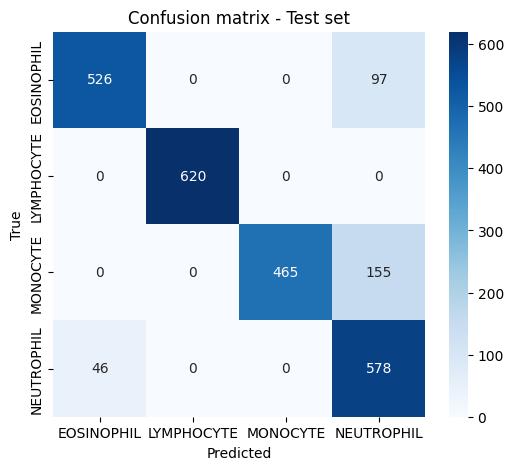

In [11]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_dataset])
y_pred = np.argmax(model.predict(test_dataset), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix - Test set')
plt.show()